## Models from molecular biology

In this notebook, we will explore a genetic toggle switch and a model that elucidates the crux of cell cycle regulation. A common theme between these two models is the antagonistic interactions between components. These interactions are mediated mostly via transcription factors that repress the expression of other components from the genetic/biochemical networks. In trying to understand the qualitative picture we will meet familiar figures from  our previous encounters as well as some new ones yet to be explored. Both the examples are taken from this textbook:

![Main reference](https://mediacdn.nhbs.com/jackets/jackets_resizer_xlarge/20/205369.jpg)

In [84]:
#using Pkg; Pkg.add("NonlinearSolve")
#using Pkg; Pkg.add("NLsolve")
#Pkg.add("DataFrames")
#Pkg.add("CSV")


In [86]:
using DifferentialEquations
import NLsolve as NLS
import NonlinearSolve as nonls
using CairoMakie
using CSV

## A genetic toggle switch

$$
\begin{split}
\frac{du}{dt} = \frac{\alpha_1}{1 + v^n} - u\\
\frac{dv}{dt} = \frac{\alpha_1}{1+u^m}-v
\end{split}
$$


In [41]:
function toggle_switch!(dx,x,p,t)
        u,v = x
        α₁ , α₂, n, m = p
        dx[1] = α₁/(1 + v^n) - u
        dx[2] = α₂/(1 + u^m) - v
end

toggle_switch! (generic function with 1 method)

In [15]:
function elem_of_f(f!, elem, u, param, t)
    du = zeros(length(u))
    f!(du, u, param, t)
    return du[elem]
end

elem_of_f (generic function with 1 method)

In [67]:
function draw_nullcline!(ax, f!, xory, param, color, linewidth, xmax, ymax)
    
    time_now = 0.0
    
    xs = LinRange(0,xmax,100)
    ys = LinRange(0,ymax,100)
    
    t = 0
    dxs = [elem_of_f(f!, xory, [x,y], param, t) for x in xs, y in ys]
    contour!(ax, xs, ys, dxs, levels=[0.0], color=color, linewidth=linewidth)
end

draw_nullcline! (generic function with 2 methods)

In [51]:
params = [3.0,3.0,3.0,3.0]
l_init_guess = [[0.0,40.0],[1,1], [40,0]]
l_sols = []

function toggle_rhs!(du, init_guess, prarams)
    
    toggle_switch!(du,init_guess, params, 0.0)
    
end

# nlprob =  nonls.NonlinearProblem(toggle_rhs!, init_guess, params)
# sol = nonls.solve(nlprob, NewtonRaphson())
for init_guess in l_init_guess
    println(init_guess)
    nlprob = nonls.NonlinearProblem(toggle_rhs!, init_guess, params)
    sol = nonls.solve(nlprob, NewtonRaphson())
    push!(l_sols, sol.u)
end

[0.0, 40.0]
[1.0, 1.0]
[40.0, 0.0]


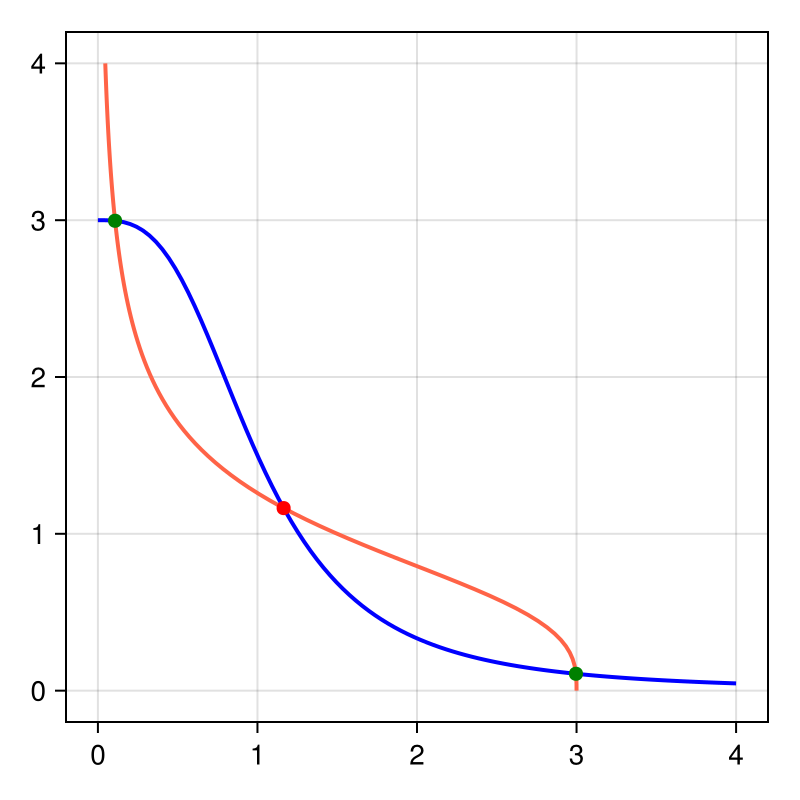

In [62]:

fig = Figure(size=(400,400))
ax = Axis(fig[1,1])
draw_nullcline!(ax, toggle_switch!, 1, params, :tomato, 2)
draw_nullcline!(ax, toggle_switch!, 2, params, :blue, 2)
l_colors = [:green, :red, :green]
iter_ = 1
for (x,y) in l_sols
    scatter!(ax, x, y, color=l_colors[iter_], markersize=10)
    iter_ += 1
end
fig

## Cyclin-APC antagonism

$$
\begin{split}
\frac{dY}{dt} = k1 - (k_{2p} + k_{2pp}P)Y\\
\frac{dP}{dt} = \frac{V_i(1-P)}{J_3 + (1-P)}-\frac{V_aP}{J_4 + P}
\end{split}
$$

we assume that 
$V_i = (k_{3p} + k_{3pp}A)$, $V_a = k_4mY$


Here,

Y --> Concentration of CyclinB that binds cyclin kinases and makes the cell transition from G1 to commit to mitosis at very low concentration

P --> Concentration of Cdh1, a partner of APC (anaphase promoting complex) labels other proteins for destruction including cyclinB





In [63]:
function tyson_simplest!(du, u, p, t)
    Y,P = u
    k1, k2p, k2pp, k3p, k3pp, k4, A, m, J3, J4 = p
    factive(P) = (k3p+k3pp*A)/(J3+1-P)
    fdecay(Y,P) = (k4*m*Y)/(J4+P)
    du[1] = k1 - (k2p+k2pp*P)*Y
    du[2] = factive(P)*(1-P)-fdecay(Y,P)*P 
end

tyson_simplest! (generic function with 1 method)

In [70]:
params = [0.04, 0.04, 1.0, 1.0, 10.0, 35.0, 0, 0.3, 0.04, 0.04]
l_init_guess = [[0.0,1.0],[0.4,0.2], [1,0]]
l_sols = []

function tysonSimplest_rhs!(du, init_guess, prarams)
    
    tyson_simplest!(du,init_guess, params, 0.0)
    
end

# nlprob =  nonls.NonlinearProblem(toggle_rhs!, init_guess, params)
# sol = nonls.solve(nlprob, NewtonRaphson())
for init_guess in l_init_guess
    println(init_guess)
    nlprob = nonls.NonlinearProblem(tysonSimplest_rhs!, init_guess, params)
    sol = nonls.solve(nlprob, NewtonRaphson())
    push!(l_sols, sol.u)
end

[0.0, 1.0]
[0.4, 0.2]
[1.0, 0.0]


[0.0, 1.0]
[0.4, 0.2]
[1.0, 0.0]
[0.0, 1.0]


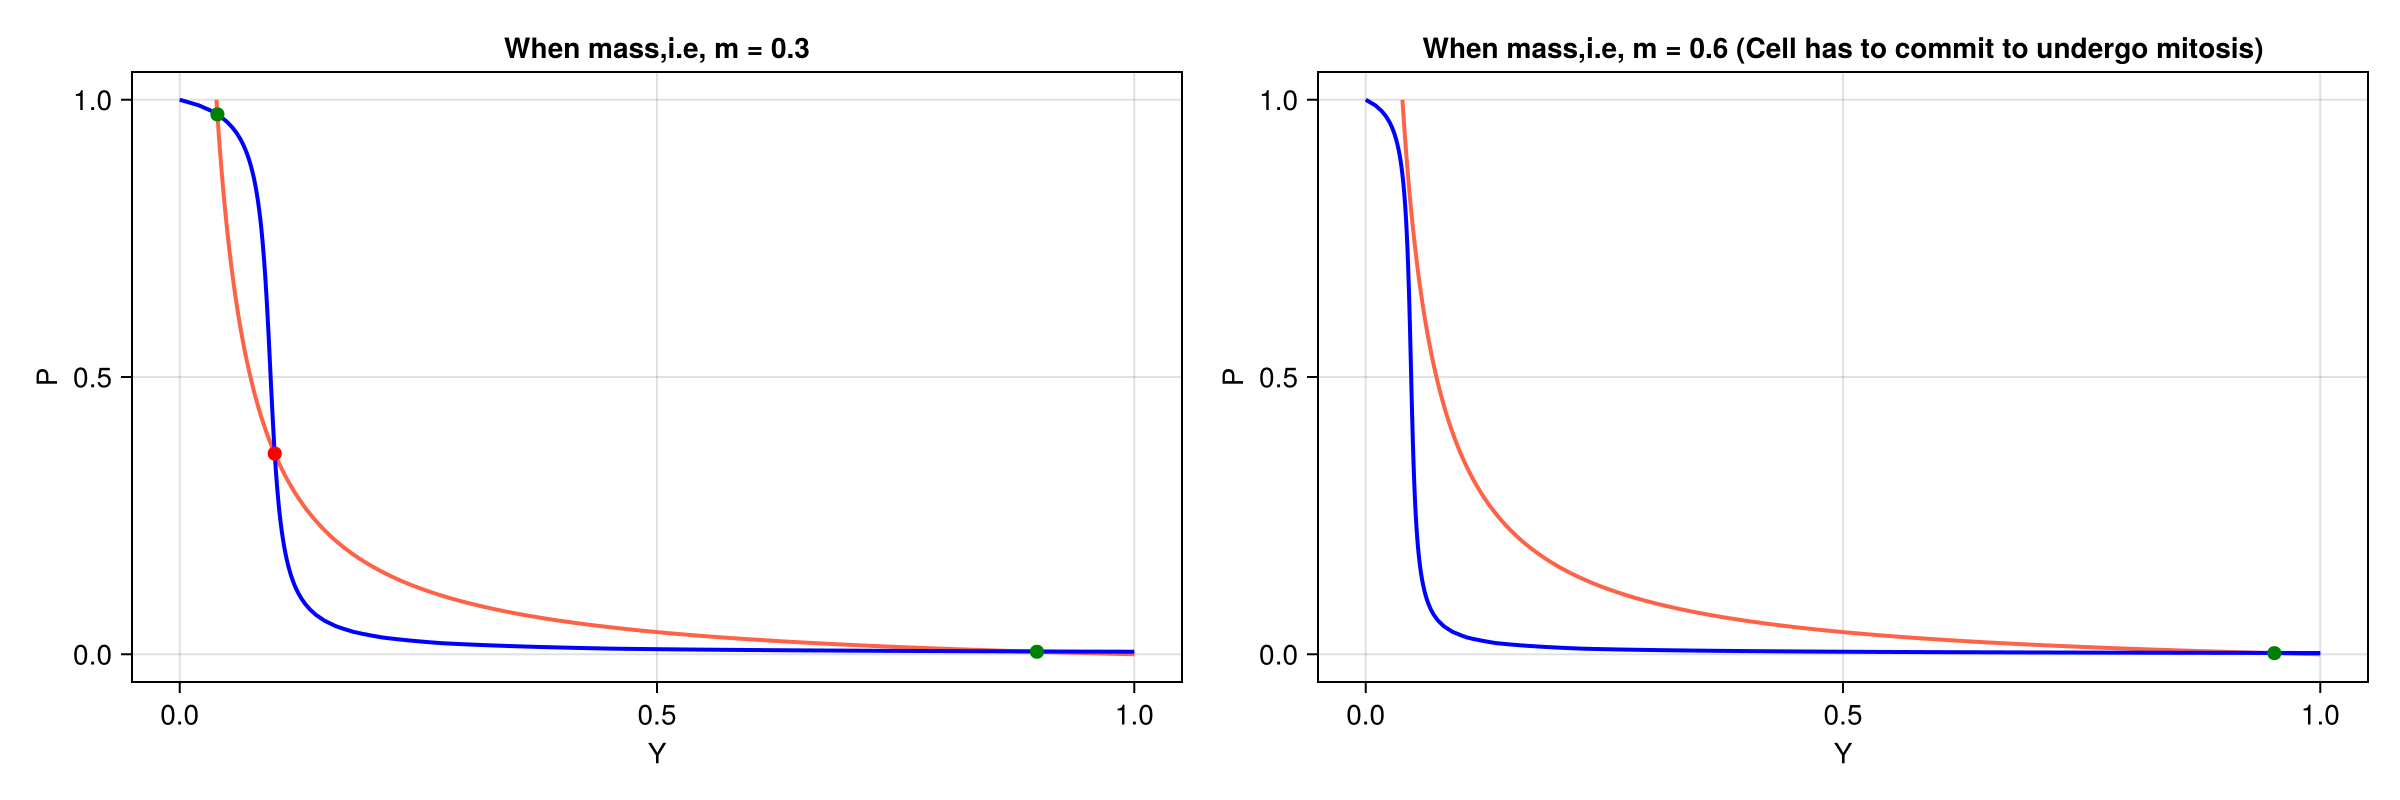

In [80]:
fig = Figure(size=(1200,400))
ga = fig[1,1] 
gb = fig[1,2] 
ax1 = Axis(ga[1,1], title="When mass,i.e, m = 0.3", xlabel= "Y", ylabel= "P")
ax2 = Axis(gb[1,1], title="When mass,i.e, m = 0.6 (Cell has to commit to undergo mitosis)", xlabel= "Y", ylabel= "P")


params = [0.04, 0.04, 1.0, 1.0, 10.0, 35.0, 0, 0.3, 0.04, 0.04]
l_init_guess = [[0.0,1.0],[0.4,0.2], [1,0]]
l_sols = []
for init_guess in l_init_guess
    println(init_guess)
    nlprob = nonls.NonlinearProblem(tysonSimplest_rhs!, init_guess, params)
    sol = nonls.solve(nlprob, NewtonRaphson())
    push!(l_sols, sol.u)
end
draw_nullcline!(ax1, tyson_simplest!, 1, params, :tomato, 2, 1.0, 1.0)
draw_nullcline!(ax1, tyson_simplest!, 2, params, :blue, 2, 1.0, 1.0)

l_colors = [:green, :red, :green]
iter_ = 1
for (x,y) in l_sols
    scatter!(ax1, x, y, color=l_colors[iter_], markersize=10)
    iter_ += 1
end

params = [0.04, 0.04, 1.0, 1.0, 10.0, 35.0, 0, 0.6, 0.04, 0.04]
l_init_guess = [[0.0,1.0]]
l_sols = []
draw_nullcline!(ax2, tyson_simplest!, 1, params, :tomato, 2, 1.0, 1.0)
draw_nullcline!(ax2, tyson_simplest!, 2, params, :blue, 2, 1.0, 1.0)
l_colors = [:green, :red, :green]
for init_guess in l_init_guess
    println(init_guess)
    nlprob = nonls.NonlinearProblem(tysonSimplest_rhs!, init_guess, params)
    sol = nonls.solve(nlprob, NewtonRaphson())
    push!(l_sols, sol.u)
end
iter_ = 1
for (x,y) in l_sols
    scatter!(ax2, x, y, color=l_colors[iter_], markersize=10)
    iter_ += 1
end
fig

In [123]:
bif_dat = CSV.File("bifurcDiag_simplestTyson.dat");

In [98]:
using DataFrames

In [127]:
dat = DataFrame(bif_dat);

In [124]:
dat_sh = dat[:,[1,4,7]];

In [125]:
filtered_df_st = filter(row -> row["2"] in [1], dat_sh);
filtered_df_u = filter(row -> row["2"] in [2], dat_sh);

In [130]:
fig = Figure(size=(1200,400))
ax = Axis(fig[1,1], title="Bifurcation diagram for the simplest cell cycle model", xlabel="m (mass)", ylabel="Y")
scatter!(ax, filtered_df_st[!,"0.1"], filtered_df_st[!,"0.0386842"], color=:red)
scatter!(ax, filtered_df_u[!,"0.1"], filtered_df_u[!,"0.0386842"], color=:black)
xlims!(0.0,1.0)


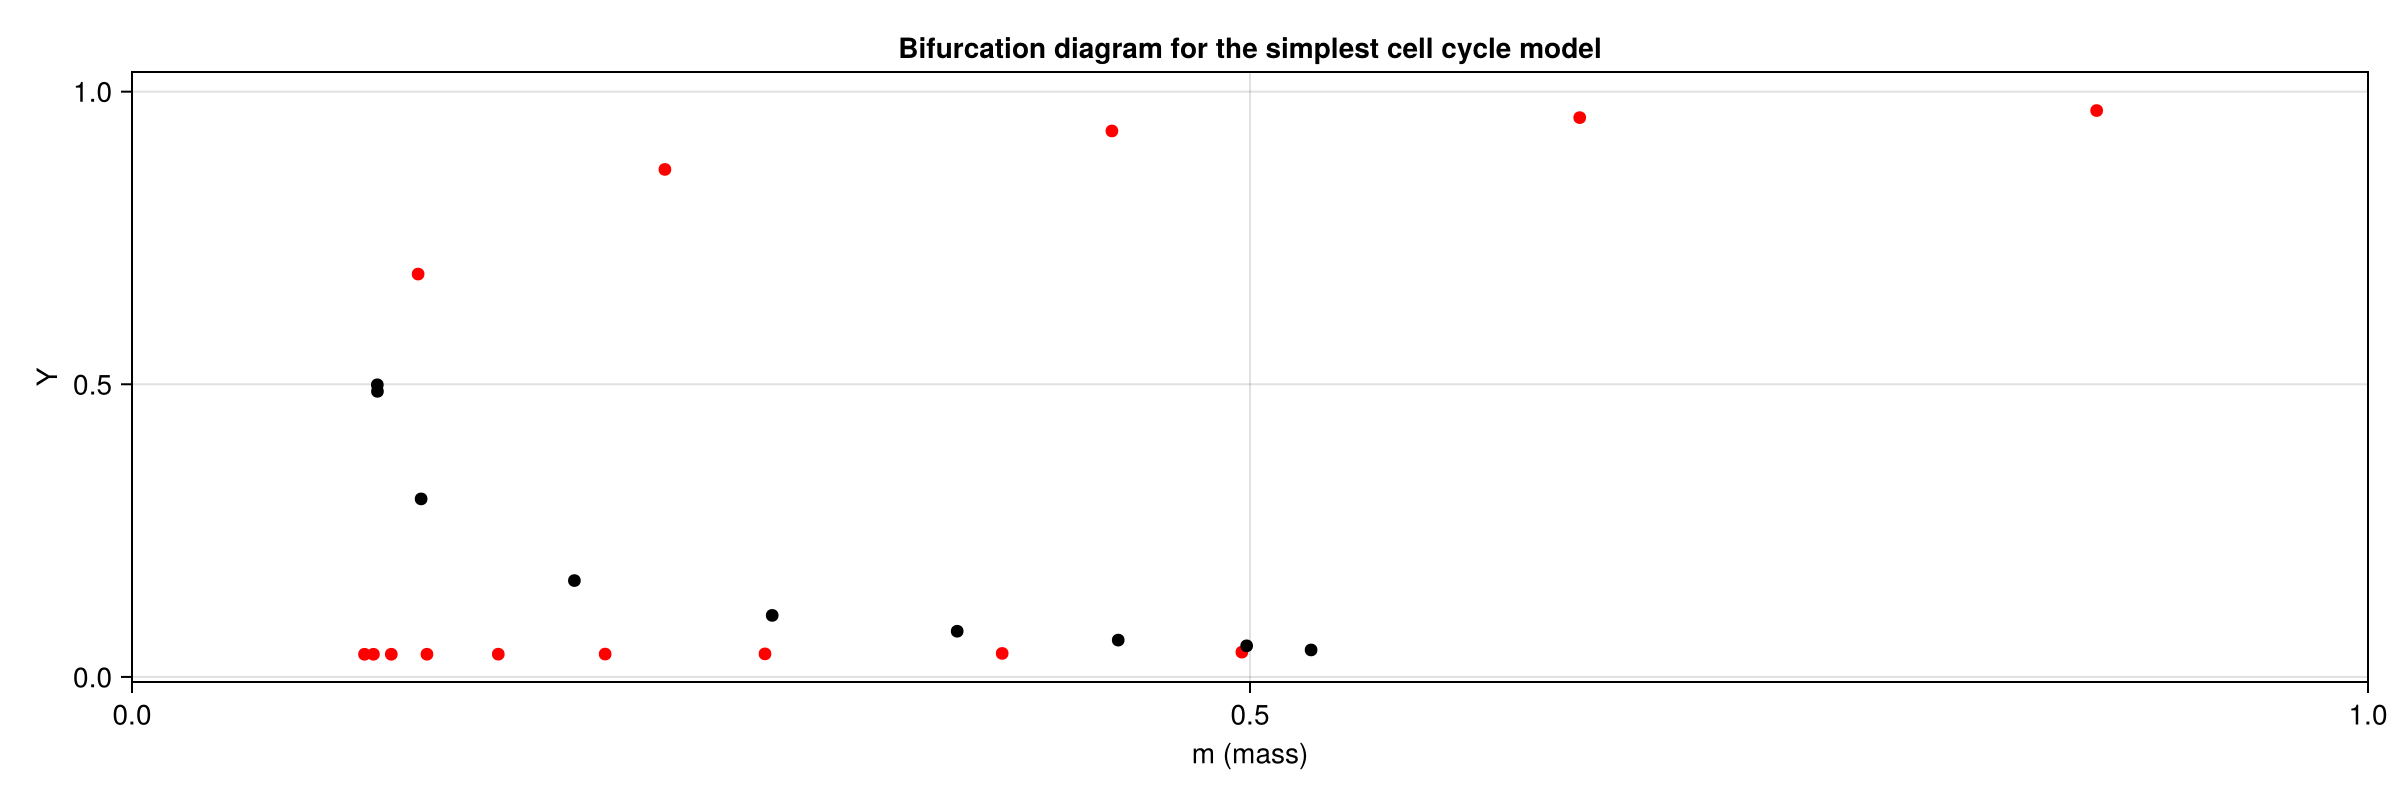

In [131]:
fig

In [193]:
bif_diag = CSV.File("diagram_ypa.dat");

In [194]:
diag_ypa = DataFrame(bif_diag);

In [249]:
br_1 = filter(row -> row["4"] in [1], diag_ypa);
br_2 = filter(row -> row["4"] in [2], diag_ypa);
br_3 = filter(row -> row["4"] in [3], diag_ypa);
br_4 = filter(row -> row["4"] in [4], diag_ypa);

fig = Figure(size=(1200,1800))
ga = fig[1,1]
gb = fig[2,1]
ax1 = Axis(ga[1,1], title="Bifurcation diagram for the simplest cell cycle model", xlabel="m (mass)", ylabel="Y")
ax2 = Axis(gb[1,1], title="Bifurcation diagram for the simplest cell cycle model", xlabel="m (mass)", ylabel="Y")

scatter!(ax1, br_1[!,"1"], br_1[!,"0.364961"], color=:red)
scatter!(ax1, br_2[!,"1"], br_2[!,"0.364961"], color=:black, marker=:xcross,markersize=5)
scatter!(ax1, br_3[!,"1"], br_3[!,"0.364961"], color=:blue, marker=:diamond,markersize=5)
scatter!(ax1, br_4[!,"1"], br_4[!,"0.364961"], alpha=0.2, color=:blue, strokecolor=:black, marker=:circle,markersize=10)
scatter!(ax1, br_3[!,"1"], br_3[!,"0.0389459"], color=:blue,  marker=:diamond,markersize=5)
scatter!(ax1, br_4[!,"1"], br_4[!,"0.0389459"], alpha=0.2, color=:blue, strokecolor=:black, marker=:circle,markersize=10)



scatter!(ax2, br_1[!,"1"], br_1[!,"0.364961"], color=:red)
scatter!(ax2, br_2[!,"1"], br_2[!,"0.364961"], color=:black, marker=:xcross,markersize=5)
scatter!(ax2, br_3[!,"1"], br_3[!,"0.364961"], color=:blue, marker=:diamond,markersize=5)
scatter!(ax2, br_4[!,"1"], br_4[!,"0.364961"], alpha=0.2, color=:blue, strokecolor=:black, marker=:circle,markersize=10)
scatter!(ax2, br_3[!,"1"], br_3[!,"0.0389459"], color=:blue,  marker=:diamond,markersize=5)
scatter!(ax2, br_4[!,"1"], br_4[!,"0.0389459"], alpha=0.2, color=:blue, strokecolor=:black, marker=:circle,markersize=10)

#scatter!(ax, filtered_df_u[!,"0.1"], filtered_df_u[!,"0.0386842"], color=:black)
xlims!(ax1, 0.0, 10)
ylims!(ax1, 0.0, 0.8)

xlims!(ax2, 0.0, 2.7)
ylims!(ax2, 0.0, 0.8)



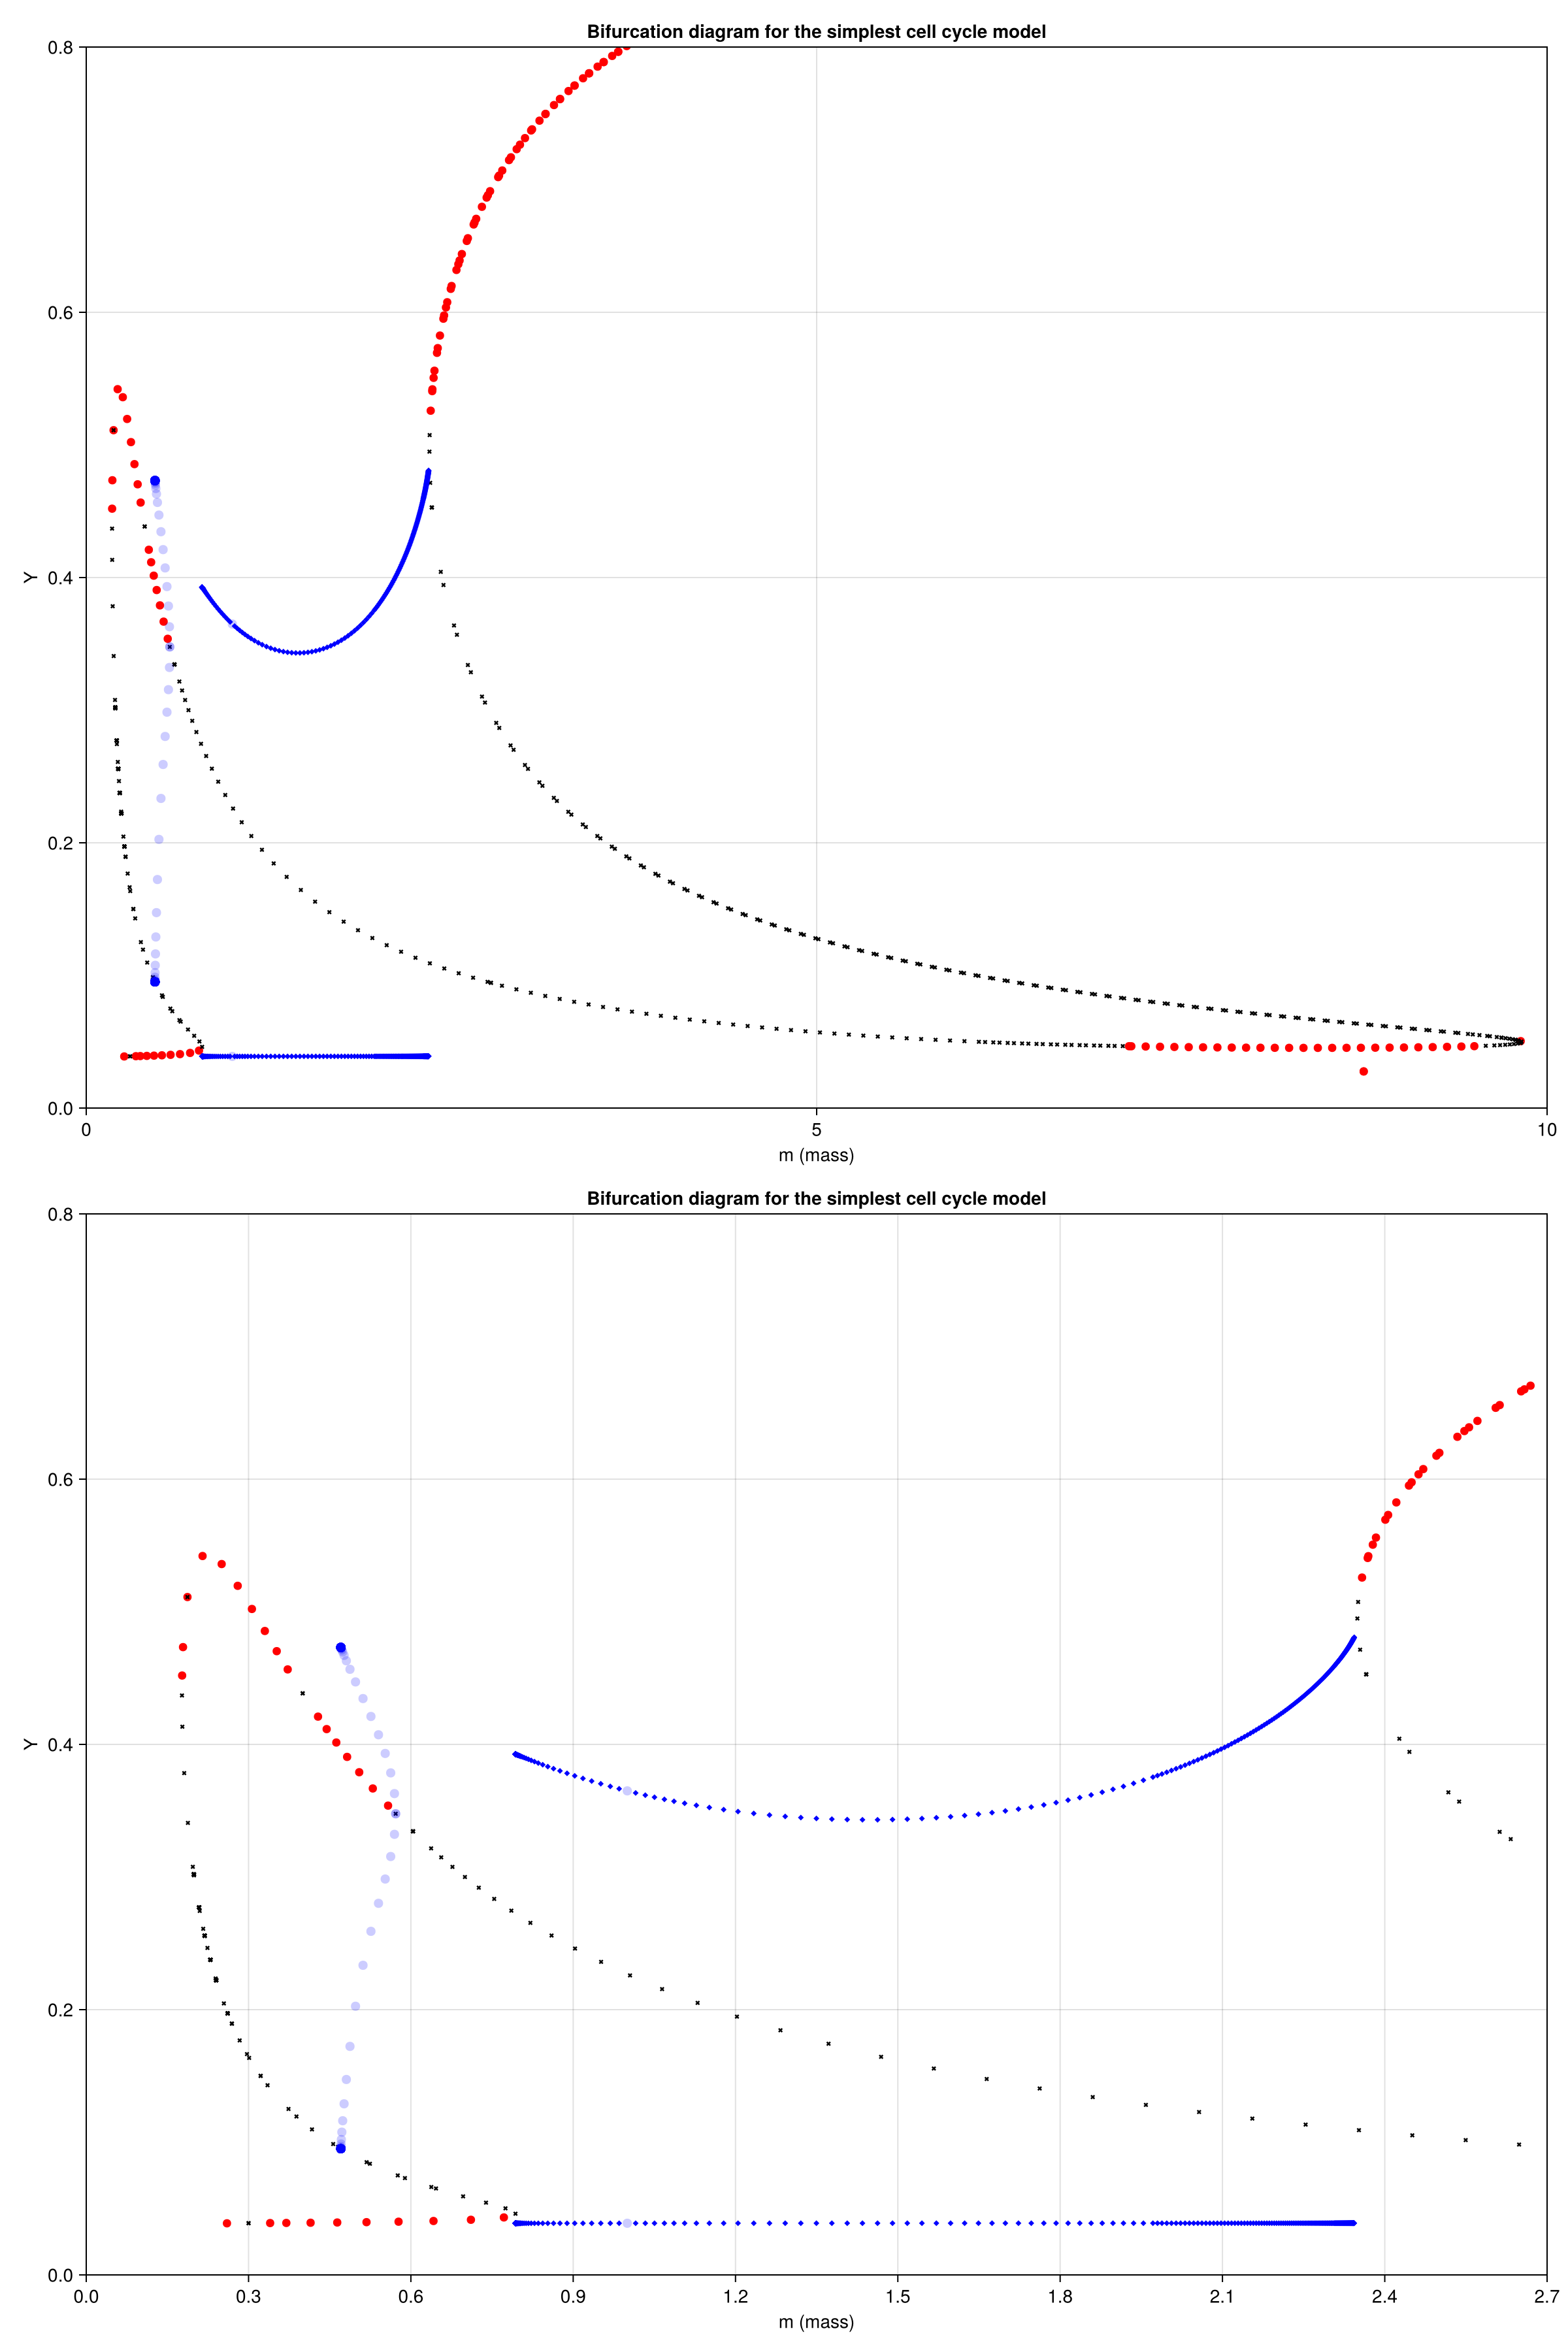

In [250]:
fig